In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
! pip install umap-learn

In [3]:
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target

In [8]:
import umap

pca = PCA(n_components=2).fit_transform(X)
tsne = TSNE(n_components=2,perplexity=30,random_state=42).fit_transform(X)
umap_p = umap.UMAP(n_components=2,n_neighbors=15,min_dist=0.1,random_state=42).fit_transform(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


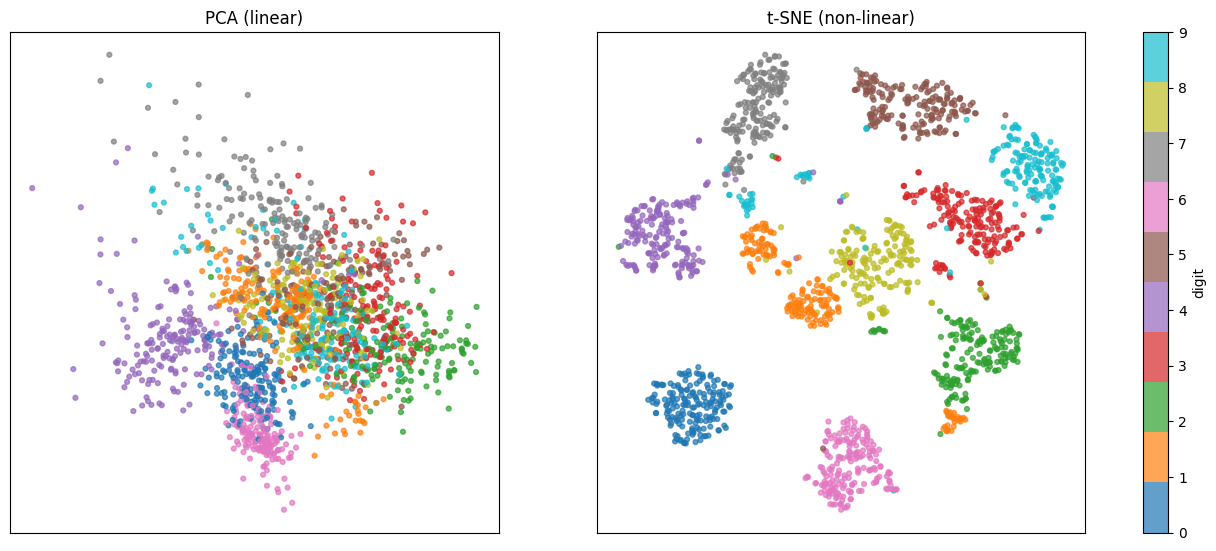

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
for a, emb, name in [(ax[0], pca, 'PCA (linear)'), (ax[1], tsne, 't-SNE (non-linear)')]:
    sc = a.scatter(emb[:,0], emb[:,1], c=y, cmap='tab10', s=12, alpha=0.7)
    a.set_title(name); a.set_xticks([]); a.set_yticks([])
plt.colorbar(sc, ax=ax, label='digit', fraction=0.025)
plt.savefig('tsne.png', dpi=110, bbox_inches='tight'); plt.show()

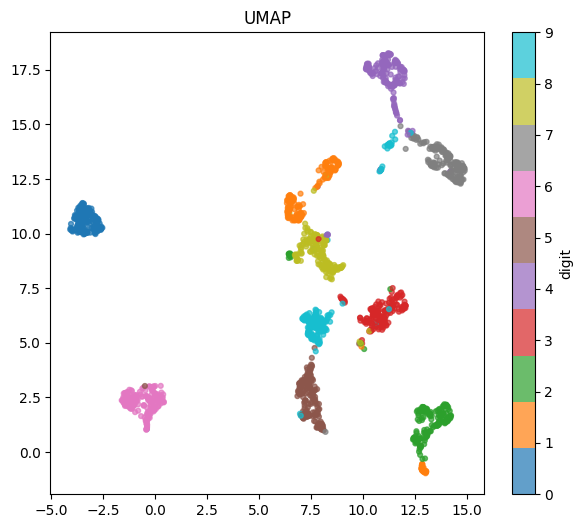

In [9]:
plt.figure(figsize=(7,6))
plt.scatter(
    umap_p[:,0],
    umap_p[:,1],
    c=y,
    cmap='tab10',
    s=12,
    alpha=0.7
)
plt.colorbar(label='digit')
plt.title("UMAP")
plt.show()